# Evaluation: LLM vs Traditional NLP

This notebook compares the LLM-based
classification pipeline against traditional NLP techniques on the same
data. Three comparison axes are presented:

1. Supervised baselines on the gold standard (200 tweets): TF-IDF
   features with Logistic Regression, Linear SVM, and Multinomial Naive
   Bayes evaluated with stratified 5-fold cross-validation for both
   topic and stance classification.
2. Unsupervised LDA topic modeling on the full corpus (11,866
   tweets): discovers latent topics and maps them to LLM categories.
3. Zero-shot multilingual BERT (mDeBERTa-v3-base) on the gold
   standard: no training, purely inference-time classification — the
   methodological middle ground between classical NLP and LLM.

The supervised and zero-shot baselines are evaluated against the human gold-standard annotations using accuracy and Cohen’s kappa. Their results are then compared with the LLM-based classification. LDA is used as an exploratory unsupervised baseline and compared with the LLM taxonomy through topic-level overlap.

Input files:
- `classified_all_tweets_final_v2_clean.csv` — full LLM-classified corpus
- `gold_standard/gold_standard_annotator_A.xlsx` — human annotations A
- `gold_standard/gold_standard_annotator_B.xlsx` — human annotations B

## Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

TOPIC_LABELS = [
    'Economy and Employment',
    'Welfare, Housing and Social Policy',
    'National Politics and Governance',
    'International Affairs',
    'Immigration and Security',
    'Rights and Equality',
    'Other',
]
STANCE_LABELS = ['Against', 'In favor', 'Neutral', 'Unclear']

# LLM performance (gold standard evaluation)
LLM_RESULTS = {
    'A': {'topic_acc': 0.750, 'topic_kappa': 0.684,
          'stance_acc': 0.800, 'stance_kappa': 0.647},
    'B': {'topic_acc': 0.710, 'topic_kappa': 0.639,
          'stance_acc': 0.765, 'stance_kappa': 0.583},
}

## Load data

In [2]:
# Full corpus (for LDA)
df_full = pd.read_csv('classified_all_tweets_final_v2_clean.csv', parse_dates=['date'])
print(f'Full corpus: {len(df_full):,} tweets')

# Gold standard (for supervised + zero-shot evaluation)
gold = {}
for ann in ['A', 'B']:
    g = pd.read_excel(f'gold_standard/gold_standard_annotator_{ann}.xlsx')
    g['tweet_norm'] = g['tweet'].str.strip().str.lower()
    gold[ann] = g
    print(f'Annotator {ann}: {len(g)} tweets')

# Merge gold with LLM predictions to get aligned dataset
model = df_full.copy()
model['tweet_norm'] = model['tweet'].str.strip().str.lower()

merged = {}
for ann in ['A', 'B']:
    m = gold[ann].merge(
        model[['tweet_norm', 'tweet_id', 'topic', 'stance']],
        on='tweet_norm', how='inner', suffixes=('_gold', '_model')
    ).rename(columns={
        'annotator_topic':  'gold_topic',
        'annotator_stance': 'gold_stance',
        'topic':  'model_topic',
        'stance': 'model_stance',
    })
    merged[ann] = m
    print(f'Matched {len(m)}/{len(gold[ann])} tweets for annotator {ann}')

Full corpus: 11,866 tweets
Annotator A: 200 tweets
Annotator B: 200 tweets
Matched 200/200 tweets for annotator A
Matched 200/200 tweets for annotator B


## Supervised baselines on the gold standard

### Methodology

This section evaluates three supervised NLP baselines using the manually annotated gold standard. The objective is to compare the performance of traditional machine learning approaches with the LLM-based classification under a low-data setting.

Three pipelines are evaluated:

- TF-IDF + Logistic Regression
- TF-IDF + Linear Support Vector Machine
- TF-IDF + Multinomial Naive Bayes

All models are trained and evaluated separately for two tasks: topic classification and stance classification. Topic classification is formulated as a seven-class problem, while stance classification is formulated as a four-class problem. The annotations from each human annotator are used as independent ground-truth references, allowing the evaluation to account for annotation variability.

TF-IDF is used to convert the tweet text into numerical features. The vectorizer combines word n-grams and character n-grams. Word n-grams from 1 to 2 capture individual words and short expressions, while character n-grams from 2 to 4 capture subword patterns, spelling variations, hashtags, abbreviations and morphology. This is useful for Spanish-language tweets because it avoids relying on a language-specific tokenizer and makes the representation more robust to noisy social media text.

Stratified 5-fold cross-validation is used because the gold standard contains a limited number of manually annotated tweets. Stratification preserves the class distribution in each fold, reducing the risk that minority categories disappear from the training or test split. In each iteration, the model is trained on four folds and evaluated on the remaining fold. The final results are obtained by averaging performance across the five folds.

The main evaluation metrics are accuracy and Cohen’s kappa. Accuracy measures the proportion of correct predictions, while Cohen’s kappa accounts for agreement expected by chance. Kappa is especially relevant in this task because the class distribution is imbalanced and some categories are more frequent than others.

In [ ]:
def make_pipelines():
    tfidf_word = TfidfVectorizer(
        analyzer='word', ngram_range=(1, 2), max_features=20000,
        sublinear_tf=True, min_df=1, strip_accents=None, lowercase=True
    )
    tfidf_char = TfidfVectorizer(
        analyzer='char_wb', ngram_range=(2, 4), max_features=15000,
        sublinear_tf=True, min_df=1, strip_accents=None, lowercase=True
    )
    from sklearn.pipeline import FeatureUnion
    combined = FeatureUnion([
        ('word', tfidf_word),
        ('char', tfidf_char),
    ])

    return {
        'LR (TF-IDF)':  Pipeline([('feat', combined),
                                   ('clf',  LogisticRegression(C=1, max_iter=1000,
                                                               class_weight='balanced',
                                                               random_state=42))]),
        'SVM (TF-IDF)': Pipeline([('feat', combined),
                                   ('clf',  LinearSVC(C=0.5, max_iter=2000,
                                                      class_weight='balanced',
                                                      random_state=42))]),
        'NB (TF-IDF)':  Pipeline([('feat', TfidfVectorizer(
                                               analyzer='word', ngram_range=(1,2),
                                               max_features=15000, sublinear_tf=False,
                                               min_df=1, lowercase=True)),
                                   ('clf',  MultinomialNB(alpha=0.1))]),
    }


def evaluate_pipelines(texts, labels, label_set, n_splits=5, seed=42):
    """Run 5-fold CV for each pipeline; return accuracy and kappa."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    results = []
    for name, pipe in make_pipelines().items():
        accs, kappas = [], []
        for tr_idx, te_idx in cv.split(texts, labels):
            X_tr = [texts[i] for i in tr_idx]
            X_te = [texts[i] for i in te_idx]
            y_tr = [labels[i] for i in tr_idx]
            y_te = [labels[i] for i in te_idx]
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            accs.append(accuracy_score(y_te, y_pred))
            try:
                kappas.append(cohen_kappa_score(y_te, y_pred))
            except Exception:
                kappas.append(np.nan)
        results.append({
            'Model': name,
            'Accuracy (mean)': np.mean(accs),
            'Accuracy (std)':  np.std(accs),
            "Kappa (mean)":    np.nanmean(kappas),
            "Kappa (std)":     np.nanstd(kappas),
        })
    return pd.DataFrame(results)


all_results = {}
for ann in ['A', 'B']:
    df_g = merged[ann]
    texts = df_g['tweet'].tolist()

    print(f'\n=== Annotator {ann} ===')

    print('  Topic classification:')
    topic_res = evaluate_pipelines(texts, df_g['gold_topic'].tolist(), TOPIC_LABELS)
    topic_res['Task'] = 'Topic'
    print(topic_res[['Model','Accuracy (mean)','Kappa (mean)']].to_string(index=False))

    print('  Stance classification:')
    stance_res = evaluate_pipelines(texts, df_g['gold_stance'].tolist(), STANCE_LABELS)
    stance_res['Task'] = 'Stance'
    print(stance_res[['Model','Accuracy (mean)','Kappa (mean)']].to_string(index=False))

    all_results[ann] = pd.concat([topic_res, stance_res], ignore_index=True)


=== Annotator A ===
  Topic classification:
       Model  Accuracy (mean)  Kappa (mean)
 LR (TF-IDF)            0.555      0.413690
SVM (TF-IDF)            0.560      0.423921
 NB (TF-IDF)            0.465      0.242984
  Stance classification:
       Model  Accuracy (mean)  Kappa (mean)
 LR (TF-IDF)            0.655      0.227793
SVM (TF-IDF)            0.660      0.202378
 NB (TF-IDF)            0.625      0.082266

=== Annotator B ===
  Topic classification:
       Model  Accuracy (mean)  Kappa (mean)
 LR (TF-IDF)            0.580      0.456052
SVM (TF-IDF)            0.565      0.437198
 NB (TF-IDF)            0.460      0.265770
  Stance classification:
       Model  Accuracy (mean)  Kappa (mean)
 LR (TF-IDF)             0.74      0.452716
SVM (TF-IDF)             0.71      0.372701
 NB (TF-IDF)             0.69      0.317027


### Comparative summary: traditional NLP vs LLM

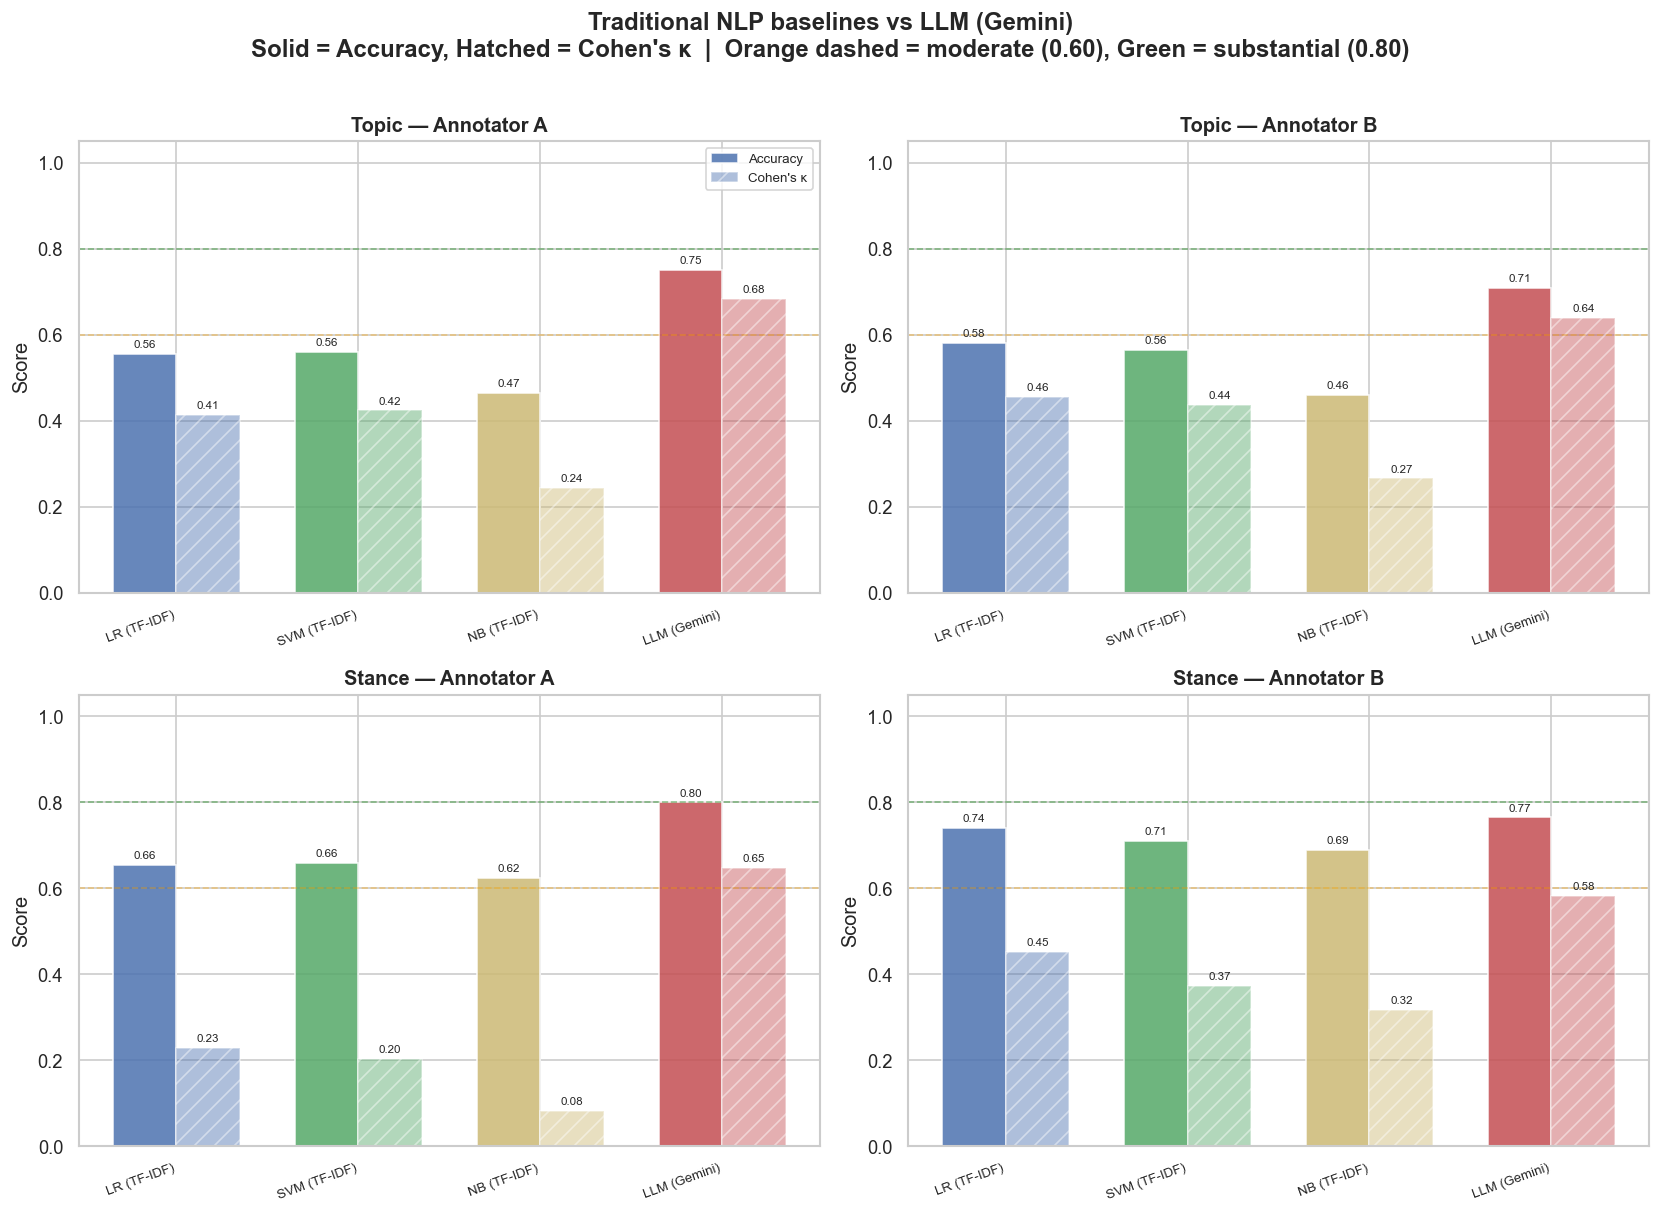


=== Full comparison table ===

Annotator A:
  Task        Model  Accuracy  Kappa  LLM Acc  LLM Kappa  Δ Acc  Δ Kappa
 Topic  LR (TF-IDF)     0.555 0.4137     0.75      0.684  0.195   0.2703
 Topic SVM (TF-IDF)     0.560 0.4239     0.75      0.684  0.190   0.2601
 Topic  NB (TF-IDF)     0.465 0.2430     0.75      0.684  0.285   0.4410
Stance  LR (TF-IDF)     0.655 0.2278     0.80      0.647  0.145   0.4192
Stance SVM (TF-IDF)     0.660 0.2024     0.80      0.647  0.140   0.4446
Stance  NB (TF-IDF)     0.625 0.0823     0.80      0.647  0.175   0.5647

Annotator B:
  Task        Model  Accuracy  Kappa  LLM Acc  LLM Kappa  Δ Acc  Δ Kappa
 Topic  LR (TF-IDF)     0.580 0.4561    0.710      0.639  0.130   0.1829
 Topic SVM (TF-IDF)     0.565 0.4372    0.710      0.639  0.145   0.2018
 Topic  NB (TF-IDF)     0.460 0.2658    0.710      0.639  0.250   0.3732
Stance  LR (TF-IDF)     0.740 0.4527    0.765      0.583  0.025   0.1303
Stance SVM (TF-IDF)     0.710 0.3727    0.765      0.583  0.055  

In [4]:
def build_comparison_table(ann):
    llm = LLM_RESULTS[ann]
    rows = []
    for _, r in all_results[ann].iterrows():
        task  = r['Task'].lower()
        llm_acc = llm[f'{task}_acc']
        llm_kap = llm[f'{task}_kappa']
        rows.append({
            'Task':       r['Task'],
            'Model':      r['Model'],
            'Accuracy':   round(r['Accuracy (mean)'], 4),
            'Kappa':      round(r['Kappa (mean)'],    4),
            'LLM Acc':    llm_acc,
            'LLM Kappa':  llm_kap,
            'Δ Acc':      round(llm_acc - r['Accuracy (mean)'], 4),
            'Δ Kappa':    round(llm_kap - r['Kappa (mean)'],    4),
        })
    return pd.DataFrame(rows)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
method_colors = {
    'LR (TF-IDF)':  '#4C72B0',
    'SVM (TF-IDF)': '#55A868',
    'NB (TF-IDF)':  '#CCB974',
    'LLM (Gemini)': '#C44E52',
}

for col, ann in enumerate(['A', 'B']):
    comp = build_comparison_table(ann)

    for row, task in enumerate(['Topic', 'Stance']):
        ax = axes[row, col]
        sub = comp[comp['Task'] == task].copy()
        llm_row = sub.iloc[0]

        models = list(sub['Model']) + ['LLM (Gemini)']
        accs   = list(sub['Accuracy']) + [llm_row['LLM Acc']]
        kappas = list(sub['Kappa'])    + [llm_row['LLM Kappa']]

        x = np.arange(len(models))
        w = 0.35
        bars_a = ax.bar(x - w/2, accs,   w, label='Accuracy',
                        color=[method_colors.get(m,'grey') for m in models],
                        alpha=0.85, edgecolor='white')
        bars_k = ax.bar(x + w/2, kappas, w, label="Cohen's κ",
                        color=[method_colors.get(m,'grey') for m in models],
                        alpha=0.45, edgecolor='white', hatch='//')

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.set_title(f'{task} — Annotator {ann}', fontweight='bold')
        ax.axhline(0.60, color='orange', ls='--', alpha=0.4, linewidth=1)
        ax.axhline(0.80, color='green',  ls='--', alpha=0.4, linewidth=1)

        for bar in list(bars_a) + list(bars_k):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(
    'Traditional NLP baselines vs LLM (Gemini)\n'
    'Solid = Accuracy, Hatched = Cohen\'s κ  |  '
    'Orange dashed = moderate (0.60), Green = substantial (0.80)',
    fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n=== Full comparison table ===')
for ann in ['A', 'B']:
    print(f'\nAnnotator {ann}:')
    print(build_comparison_table(ann)
          [['Task','Model','Accuracy','Kappa','LLM Acc','LLM Kappa','Δ Acc','Δ Kappa']]
          .to_string(index=False))

### Interpretation of the supervised baseline results

The results show that the supervised TF-IDF baselines provide a useful but limited reference point for the classification tasks. Overall, Logistic Regression and Linear SVM are the strongest traditional NLP models, while Multinomial Naive Bayes performs worse in most settings. This pattern is expected in short-text classification, since Logistic Regression and SVM usually handle sparse high-dimensional TF-IDF representations better than Naive Bayes.

The comparison also shows that the LLM-based classification obtains higher performance than all supervised TF-IDF baselines across both tasks and both annotators. This improvement is visible in both accuracy and Cohen’s kappa, but it is especially clear in kappa. Since Cohen’s kappa corrects for chance agreement, it is more informative than accuracy in this setting, where some classes are more frequent than others.

#### Topic classification

For topic classification, the best traditional baselines are Logistic Regression and Linear SVM. Against Annotator A, Logistic Regression obtains an accuracy of 0.555 and a kappa of 0.414, while SVM obtains a similar accuracy of 0.560 and a slightly higher kappa of 0.424. Against Annotator B, Logistic Regression reaches the best traditional result, with an accuracy of 0.580 and a kappa of 0.456.

These values suggest that TF-IDF models are able to capture part of the thematic structure of the tweets. This is reasonable because some topic categories are associated with relatively clear lexical signals. For example, tweets about the economy may include terms related to employment, taxes, companies or inflation, while tweets about international affairs may include references to countries, wars, Europe or international institutions.

However, the performance remains moderate. Topic classification in this dataset is not only a lexical task. Many tweets require interpreting the political meaning of the message, the target of the statement, or the broader institutional context. Traditional TF-IDF models mainly rely on word-frequency patterns, so they may struggle when different categories share vocabulary or when the topic is expressed indirectly.

Naive Bayes obtains lower results in topic classification. Against Annotator A, it reaches 0.465 accuracy and 0.243 kappa. Against Annotator B, it obtains 0.460 accuracy and 0.266 kappa. This confirms that Naive Bayes is a weaker baseline for this task. Its independence assumption is too restrictive for political tweets, where the meaning often depends on combinations of words, names, entities and contextual references.

Compared with these baselines, the LLM obtains a clear improvement. For Annotator A, the LLM reaches 0.750 accuracy and 0.684 kappa. This represents an improvement of approximately 0.19–0.20 accuracy points and 0.26–0.27 kappa points over Logistic Regression and SVM. For Annotator B, the LLM reaches 0.710 accuracy and 0.639 kappa, improving over the best traditional baseline by 0.13 accuracy points and approximately 0.18 kappa points.

This indicates that the LLM aligns more closely with human thematic annotations than the supervised TF-IDF models. The improvement is particularly relevant because the LLM is better able to use semantic and contextual information, rather than only relying on surface-level lexical patterns.

#### Stance classification

The limitations of traditional NLP models become more visible in stance classification. Against Annotator A, Logistic Regression obtains 0.655 accuracy but only 0.228 kappa. SVM obtains a similar accuracy of 0.660 but an even lower kappa of 0.202. Naive Bayes obtains 0.625 accuracy and only 0.082 kappa.

This difference between accuracy and kappa is important. The accuracy values may seem acceptable at first, but the low kappa values show that much of the apparent performance may be explained by the class distribution. In other words, the models may be correctly predicting frequent classes, but they are not achieving strong agreement beyond chance. This is especially relevant for stance classification, where classes such as "In favor" may appear more frequently than "Against", "Neutral" or "Unclear".

Against Annotator B, the traditional baselines perform better in stance classification. Logistic Regression reaches 0.740 accuracy and 0.453 kappa, SVM reaches 0.710 accuracy and 0.373 kappa, and Naive Bayes reaches 0.690 accuracy and 0.317 kappa. These results suggest that Annotator B’s stance labels may be more aligned with the lexical patterns captured by the supervised models, or that the specific distribution of labels makes the task easier for these models.

Even so, the LLM still obtains the best results. Against Annotator A, it reaches 0.800 accuracy and 0.647 kappa. This means that the LLM improves over Logistic Regression by 0.145 accuracy points and 0.419 kappa points. Compared with SVM, the improvement is 0.140 accuracy points and 0.445 kappa points. Compared with Naive Bayes, the improvement is even larger, with 0.175 accuracy points and 0.565 kappa points.

Against Annotator B, the LLM reaches 0.765 accuracy and 0.583 kappa. The improvement over Logistic Regression is smaller than in Annotator A, but it is still positive: 0.025 accuracy points and 0.130 kappa points. This is important because Logistic Regression already performs reasonably well against Annotator B. The fact that the LLM still improves the result suggests that its advantage is consistent, even when the traditional baseline is relatively strong.

These results show that stance classification benefits strongly from contextual interpretation. A stance is not always expressed through explicit positive or negative words. It may depend on irony, criticism, political references, the target of the tweet or implicit support for a policy or actor. TF-IDF models have difficulty capturing these elements because they do not understand the communicative intention of the text. The LLM performs better because it can use broader semantic and pragmatic information.

#### Accuracy versus Cohen’s kappa

One of the most important findings is the difference between accuracy and Cohen’s kappa. In several cases, the traditional models obtain acceptable accuracy but much lower kappa. This is especially clear in stance classification against Annotator A. For example, SVM obtains 0.660 accuracy but only 0.202 kappa.

This means that accuracy alone would give an overly optimistic view of model performance. In imbalanced classification problems, a model can obtain reasonable accuracy by predicting the most frequent labels. Cohen’s kappa provides a stricter evaluation because it measures agreement after correcting for the agreement expected by chance.

For this reason, kappa should be considered the main metric for interpreting these results. From this perspective, the LLM advantage is more substantial than what accuracy alone suggests. The LLM does not only improve the number of correct predictions, but also achieves stronger agreement beyond chance.

#### Differences between annotators

The results also show some differences between Annotator A and Annotator B. For topic classification, the traditional baselines perform slightly better against Annotator B than against Annotator A. For stance classification, the difference is more visible: the TF-IDF baselines obtain much higher kappa values against Annotator B than against Annotator A.

This suggests that the task is sensitive to annotation criteria. Some tweets may be interpreted differently depending on how each annotator handles implicit stance, ambiguous political references, neutral institutional messages or unclear cases. Therefore, the variation between annotators should not be interpreted as noise only, but as evidence that topic and stance classification involve subjective and context-dependent decisions.

The LLM remains the strongest method for both annotators, which supports the robustness of the LLM-based approach. However, the different results across annotators also show that the task has an upper limit determined by human disagreement. This is important when interpreting model performance, because perfect agreement is not a realistic expectation in this type of political discourse analysis.

#### Conclusion

The supervised TF-IDF baselines are useful because they provide transparent, reproducible and interpretable reference models. Logistic Regression and Linear SVM are the strongest traditional baselines, especially for topic classification, where lexical cues are more informative. Naive Bayes performs worse, probably because its assumptions are too simple for political discourse.

However, all traditional baselines remain below the LLM-based classification. The gap is especially clear in Cohen’s kappa, which shows that the LLM achieves stronger agreement with human annotations after correcting for chance. This advantage is particularly important for stance classification, where interpretation depends on context, tone, target and implicit meaning.

## Unsupervised LDA on the full corpus

### Methodology

Latent Dirichlet Allocation (LDA) is applied to the full corpus of 11,866 tweets as an unsupervised exploratory baseline. Unlike the supervised models, LDA does not use human annotations or predefined topic labels. Instead, it identifies latent topics based on word co-occurrence patterns across the corpus.

Before fitting the model, tweets are converted into a document-term matrix using CountVectorizer. This representation is based on raw word counts rather than TF-IDF values, since LDA is a probabilistic topic model that assumes documents are generated from word-count distributions. The vectorizer uses lowercase word unigrams and removes a manually defined list of common Spanish and English stop words, as well as frequent web-related tokens such as "http", "https", "rt" and "amp".

The vocabulary is limited to a maximum of 8,000 terms. Very rare words are removed using $min_{df}$ = 5, meaning that a token must appear in at least five tweets to be included. Very frequent words are removed using $max_{df}$ = 0.9, meaning that terms appearing in more than 90% of tweets are excluded. These settings reduce noise and remove terms that are unlikely to help distinguish between latent topics.

The number of topics is set to $K$ = 7 to match the number of categories in the LLM taxonomy. This choice is made for comparability, not because LDA is expected to recover the same semantic categories. LDA topics are lexical clusters based on word co-occurrence, while the LLM categories are semantic and interpretative labels.

After fitting the model, each LDA topic is summarized using its top 15 most representative words. These word lists are manually inspected to interpret the meaning of each latent topic. Each tweet is then assigned to its dominant LDA topic, defined as the topic with the highest document-topic probability.

The alignment between LDA and the LLM taxonomy is evaluated using a row-normalized cross-tabulation between each tweet’s dominant LDA topic and its LLM-assigned category. Each row represents one LDA topic, and each column represents one LLM topic category. The values indicate the percentage of tweets within each LDA topic that were assigned to each LLM category.

For each LDA topic, the best matching LLM category is selected as the category with the highest percentage overlap. This provides an approximate topic-purity measure for each LDA cluster. High purity means that an LDA topic is mostly associated with one LLM category, while low purity means that the LDA topic mixes several LLM categories.

This analysis should not be interpreted as a direct classification benchmark. Instead, it evaluates whether a traditional unsupervised topic model can recover thematic structures similar to those obtained through LLM-based classification.

In [ ]:
# --- Preprocessing: CountVectorizer on tweet text ---
# Spanish stop words approximation via min_df + very common words
EXTRA_STOP = [
    'de','la','el','en','que','y','a','los','se','del','un','una',
    'con','por','para','es','las','al','lo','su','más','si','no',
    'le','ya','hay','pero','también','nos','este','esta','esto',
    'han','ha','he','hemos','https','rt','amp','co','http',
    'como','cuando','todo','todos','puede','desde','sobre','entre',
    'has','have','the','of','and','to','in','is','for','on','are',
    'porque','aunque','así','tan','muy','mismo','misma',
]

texts_full = df_full['tweet'].fillna('').tolist()

count_vec = CountVectorizer(
    max_features=8000,
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 1),
    stop_words=EXTRA_STOP,
    lowercase=True,
)
X_counts = count_vec.fit_transform(texts_full)
vocab    = np.array(count_vec.get_feature_names_out())

K = 7
lda = LatentDirichletAllocation(
    n_components=K,
    max_iter=20,
    learning_method='online',
    random_state=42,
    n_jobs=-1,
)
lda.fit(X_counts)
print(f'LDA perplexity (lower = better fit): {lda.perplexity(X_counts):.1f}')

LDA perplexity (lower = better fit): 2863.1


In [6]:
# --- Top words per LDA topic ---
TOP_N = 15

print(f'Top-{TOP_N} words per LDA topic (K={K}):')
print('='*70)
lda_top_words = {}
for t_idx, topic_vec in enumerate(lda.components_):
    top_ids = topic_vec.argsort()[:-TOP_N-1:-1]
    words   = vocab[top_ids]
    lda_top_words[t_idx] = words
    print(f'  LDA-{t_idx}: {" | ".join(words)}')

Top-15 words per LDA topic (K=7):
  LDA-0: mundo | años | hacer | historia | todas | enhorabuena | verde | siempre | próximo | ahora | hace | me | voz | queda | nuevo
  LDA-1: gobierno | laboral | sánchez | pedro | vivienda | sea | mejorar | va | son | reforma | está | proteger | tiene | hace | medidas
  LDA-2: gobierno | españoles | sánchez | ni | españa | pp | sus | gente | psoe | vamos | ley | contra | vox | solo | les
  LDA-3: mi | nuestro | mujeres | familia | violencia | trabajo | contra | cariño | gracias | sus | hoy | solidaridad | vida | apoyo | sociedad
  LDA-4: españa | europa | democracia | nuestra | paz | libertad | internacional | hoy | presidente | pueblo | estado | ue | nuestras | nuestros | seguridad
  LDA-5: país | hoy | gracias | derechos | nuestro | social | personas | mejor | españa | trabajadoras | tu | seguir | economía | seguimos | vida
  LDA-6: trabajo | españa | feijóo | cambio | sumar | os | español | primera | futuro | donde | elecciones | ellos | ganar | re

LDA topic → best matching LLM category:
  LDA-0 → Other  (33.4% overlap)  [mundo | años | hacer | historia | todas]
  LDA-1 → Economy and Employment  (46.9% overlap)  [gobierno | laboral | sánchez | pedro | vivienda]
  LDA-2 → National Politics and Governance  (67.2% overlap)  [gobierno | españoles | sánchez | ni | españa]
  LDA-3 → Other  (27.2% overlap)  [mi | nuestro | mujeres | familia | violencia]
  LDA-4 → International Affairs  (54.0% overlap)  [españa | europa | democracia | nuestra | paz]
  LDA-5 → Economy and Employment  (34.3% overlap)  [país | hoy | gracias | derechos | nuestro]
  LDA-6 → National Politics and Governance  (62.9% overlap)  [trabajo | españa | feijóo | cambio | sumar]


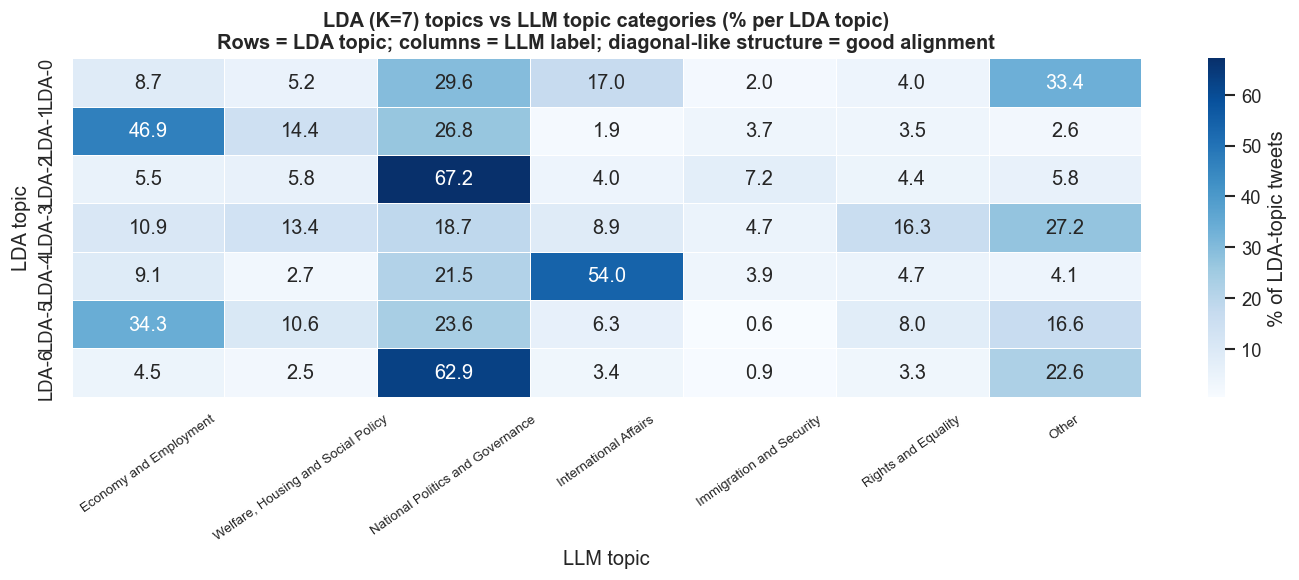

In [7]:
# --- Assign dominant LDA topic to each tweet ---
doc_topic = lda.transform(X_counts)
df_full['lda_topic_idx'] = doc_topic.argmax(axis=1)

# --- Cross-tabulate LDA topics vs LLM topics ---
ct = pd.crosstab(
    df_full['lda_topic_idx'].map(lambda x: f'LDA-{x}'),
    df_full['topic'],
    normalize='index'
) * 100
ct = ct.reindex(columns=TOPIC_LABELS, fill_value=0)

# Best matching LLM label for each LDA topic
lda_to_llm = ct.idxmax(axis=1).to_dict()
print('LDA topic → best matching LLM category:')
for lda_t, llm_t in lda_to_llm.items():
    top_w = ' | '.join(lda_top_words[int(lda_t.split('-')[1])][:5])
    match_pct = ct.loc[lda_t, llm_t]
    print(f'  {lda_t} → {llm_t}  ({match_pct:.1f}% overlap)  [{top_w}]')

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ct.round(1), annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of LDA-topic tweets'}, ax=ax)
ax.set_title(
    f'LDA (K={K}) topics vs LLM topic categories (% per LDA topic)\n'
    'Rows = LDA topic; columns = LLM label; diagonal-like structure = good alignment',
    fontweight='bold')
ax.set_xlabel('LLM topic')
ax.set_ylabel('LDA topic')
ax.tick_params(axis='x', rotation=35, labelsize=8)
plt.tight_layout()
plt.show()

In [8]:
# --- Topic coherence proxy: top-word distinctiveness ---
# Compute average pairwise Jaccard distance between LDA-topic top-word sets
top_sets = {t: set(lda_top_words[t]) for t in range(K)}

jaccard_matrix = pd.DataFrame(0.0, index=range(K), columns=range(K))
for i in range(K):
    for j in range(K):
        inter = len(top_sets[i] & top_sets[j])
        union = len(top_sets[i] | top_sets[j])
        jaccard_matrix.iloc[i, j] = inter / union if union > 0 else 0

avg_overlap = (jaccard_matrix.values.sum() - K) / (K * (K-1))
print(f'Average pairwise Jaccard overlap between LDA topic vocabularies: {avg_overlap:.3f}')
print('(Lower = more distinct topics; 0 = no shared words)')

# --- LDA per-actor topic distribution ---
print('\nLDA topic distribution by actor (% dominant topic):')
lda_actor = pd.crosstab(
    df_full['politician'],
    df_full['lda_topic_idx'].map(lambda x: f'LDA-{x}'),
    normalize='index'
) * 100
print(lda_actor.round(1).to_string())

Average pairwise Jaccard overlap between LDA topic vocabularies: 0.031
(Lower = more distinct topics; 0 = no shared words)

LDA topic distribution by actor (% dominant topic):
lda_topic_idx    LDA-0  LDA-1  LDA-2  LDA-3  LDA-4  LDA-5  LDA-6
politician                                                      
NunezFeijoo        5.9   13.3   32.0   12.9   15.7    9.9   10.3
Santi_ABASCAL      6.6   10.0   44.2    8.0   14.8    4.7   11.7
Yolanda_Diaz_      4.1   17.4    8.2   14.4   12.3   34.3    9.3
sanchezcastejon    8.9    6.7   13.7   18.2   29.6   16.6    6.5


The LDA analysis shows that unsupervised topic modelling is able to recover part of the thematic structure of the corpus, but its alignment with the LLM classification is only partial. This is expected because LDA identifies topics from word co-occurrence patterns, while the LLM taxonomy is based on semantic and contextual interpretation.

The heatmap compares each dominant LDA topic with the LLM-assigned topic categories. Since the rows are normalized, each value represents the percentage of tweets within a given LDA topic that belong to each LLM category. A strong alignment would appear as one dominant cell per row, meaning that each LDA topic mostly corresponds to one LLM category. In this case, some LDA topics show a relatively clear association with one LLM category, while others are more mixed.

The clearest alignment appears in LDA-2 and LDA-6, which are both mostly associated with National Politics and Governance. LDA-2 has 67.2% of its tweets in this category, and LDA-6 has 62.9%. This suggests that LDA can detect the strong lexical structure of national political discourse, probably because this category contains repeated references to government, Spain, political leaders and institutional conflict. However, the fact that two different LDA topics map to the same LLM category also shows that LDA may split a broad semantic category into several lexical subtopics.

LDA-4 also shows a relatively clear alignment with International Affairs, with 54.0% overlap. Its top words include terms such as “españa”, “europa”, “democracia”, “nuestra” and “paz”, which are consistent with international or geopolitical discourse. This indicates that LDA can recover topics that have distinctive vocabulary and recurrent references to international institutions, Europe, democracy or conflict.

LDA-1 is mainly associated with Economy and Employment, with 46.9% overlap. However, this alignment is weaker than in the previous cases. Its top words include “gobierno”, “laboral”, “sánchez”, “pedro” and “vivienda”, suggesting that the topic mixes economic, labour and housing-related discourse with broader government-related vocabulary. This reflects one limitation of LDA: when political topics share common actors and institutional terms, the resulting lexical clusters may not correspond cleanly to a single analytical category.

LDA-0 and LDA-3 are mapped to Other, but with relatively low overlap values: 33.4% and 27.2%, respectively. This indicates that these topics are not strongly aligned with a single LLM category. LDA-0 includes broad and generic words such as “mundo”, “años”, “hacer”, “historia” and “todas”, while LDA-3 includes terms such as “mi”, “nuestro”, “mujeres”, “familia” and “violencia”. These topics appear to group more diffuse or cross-cutting discourse, rather than a clearly defined thematic category. In the case of LDA-3, the presence of words such as “mujeres”, “familia” and “violencia” suggests that part of the topic may relate to rights, equality or social issues, but the overlap is distributed across several LLM categories.

LDA-5 is mapped to Economy and Employment, but the overlap is only 34.3%. Its top words, such as “país”, “hoy”, “gracias”, “derechos” and “nuestro”, are quite general and could appear in many types of political tweets. This topic seems to capture a broad rhetorical style rather than a precise thematic area. This again shows that LDA topics are not always equivalent to meaningful analytical categories.

The average pairwise Jaccard overlap between LDA topic vocabularies is 0.031. This is very low, meaning that the top-word vocabularies of the LDA topics are mostly distinct from each other. Therefore, the model does produce different lexical clusters. However, lexical distinctiveness does not necessarily imply semantic alignment with the LLM taxonomy. In other words, LDA finds different word groups, but these word groups do not always match the thematic categories used in the LLM classification.

The actor-level distribution provides an additional perspective. Núñez Feijóo and Santiago Abascal have a high concentration in LDA-2, which is strongly associated with National Politics and Governance. This suggests that their tweets are more frequently organized around national political conflict, government criticism and institutional discourse. Yolanda Díaz has a high concentration in LDA-5, followed by LDA-1, which are associated with economy, employment, rights and social discourse. This is consistent with her political profile and the greater presence of labour and social-policy vocabulary in her tweets. Pedro Sánchez has a high concentration in LDA-4, associated with International Affairs, and also relevant presence in LDA-3 and LDA-5, suggesting a more distributed thematic profile across international, institutional and broad political communication.

These findings support the use of LLM-based classification as the main approach for thematic analysis, while LDA serves as a transparent baseline showing what can be recovered from the corpus without labeled data or contextual reasoning.

## Zero-shot multilingual classification

Zero-shot classification is used as an additional baseline between traditional NLP models and the LLM-based approach. Unlike the supervised TF-IDF models, this method does not require training on the gold standard. Instead, it uses a pre-trained multilingual transformer model to assign each tweet to one of several candidate labels.

The model receives a tweet and a list of candidate labels expressed in natural language. It then estimates which label is most compatible with the input text. This approach is useful because it allows classification without task-specific fine-tuning, while still using a semantic model that has been trained on multilingual natural language inference data.

The model used is `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, a multilingual natural language inference model. This model is suitable for Spanish tweets because it supports multilingual inference and does not require translating the corpus into English.

Two zero-shot classification tasks are evaluated separately:

- topic classification, using the seven topic labels as candidate labels
- stance classification, using the four stance labels as candidate labels

For this baseline, the evaluation is performed against Annotator A’s gold-standard labels. The same tweets are classified twice: once for topic and once for stance. The predicted label is the highest-scoring candidate returned by the model.

The results are evaluated using accuracy and Cohen’s kappa. Accuracy measures the proportion of correct predictions, while Cohen’s kappa measures agreement after correcting for chance. As in the supervised baseline evaluation, kappa is especially important because the topic and stance distributions are imbalanced.

In [ ]:
try:
    from transformers import pipeline as hf_pipeline
    HAS_TRANSFORMERS = True
    print('transformers available — running zero-shot classification')
except ImportError:
    HAS_TRANSFORMERS = False
    print('transformers not installed.'
          ' Run: pip install transformers')
    print('Skipping Section.')

transformers available — running zero-shot classification


In [10]:
if HAS_TRANSFORMERS:
    import torch
    from transformers import pipeline as hf_pipeline

    ZS_MODEL   = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
    BATCH_SIZE = 16

    print(f'Loading {ZS_MODEL}...')
    zs_pipe = hf_pipeline(
        'zero-shot-classification',
        model=ZS_MODEL,
        device=0 if torch.cuda.is_available() else -1,
    )
    print('Model loaded.')

    # Candidate labels for topic and stance
    TOPIC_CANDIDATES  = TOPIC_LABELS
    STANCE_CANDIDATES = STANCE_LABELS

    # Use annotator A gold standard
    df_zs = merged['A'][['tweet', 'gold_topic', 'gold_stance']].copy()
    tweets_zs = df_zs['tweet'].tolist()

    print(f'Classifying {len(tweets_zs)} tweets for topic...')
    topic_preds = []
    for i in range(0, len(tweets_zs), BATCH_SIZE):
        batch = tweets_zs[i:i+BATCH_SIZE]
        out   = zs_pipe(batch, candidate_labels=TOPIC_CANDIDATES, multi_label=False)
        for res in out:
            topic_preds.append(res['labels'][0])
        if (i // BATCH_SIZE) % 5 == 0:
            print(f'  {i+len(batch)}/{len(tweets_zs)}')

    print(f'Classifying {len(tweets_zs)} tweets for stance...')
    stance_preds = []
    for i in range(0, len(tweets_zs), BATCH_SIZE):
        batch = tweets_zs[i:i+BATCH_SIZE]
        out   = zs_pipe(batch, candidate_labels=STANCE_CANDIDATES, multi_label=False)
        for res in out:
            stance_preds.append(res['labels'][0])
        if (i // BATCH_SIZE) % 5 == 0:
            print(f'  {i+len(batch)}/{len(tweets_zs)}')

    df_zs['zs_topic']  = topic_preds
    df_zs['zs_stance'] = stance_preds

    # Metrics
    zs_topic_acc   = accuracy_score(df_zs['gold_topic'],  df_zs['zs_topic'])
    zs_topic_kappa = cohen_kappa_score(df_zs['gold_topic'], df_zs['zs_topic'])
    zs_stance_acc  = accuracy_score(df_zs['gold_stance'], df_zs['zs_stance'])
    zs_stance_kappa= cohen_kappa_score(df_zs['gold_stance'], df_zs['zs_stance'])

    print(f'\nZero-shot mDeBERTa — Annotator A:')
    print(f'  Topic  — Accuracy: {zs_topic_acc:.4f}  Kappa: {zs_topic_kappa:.4f}')
    print(f'  Stance — Accuracy: {zs_stance_acc:.4f}  Kappa: {zs_stance_kappa:.4f}')
    print(f'  LLM    — Topic Acc: {LLM_RESULTS["A"]["topic_acc"]}  '
          f'Kappa: {LLM_RESULTS["A"]["topic_kappa"]}')
    print(f'  LLM    — Stance Acc: {LLM_RESULTS["A"]["stance_acc"]}  '
          f'Kappa: {LLM_RESULTS["A"]["stance_kappa"]}')
else:
    print('Zero-shot results skipped (transformers not installed).')
    print('Placeholder results for the comparison table:')
    print('  Install transformers and re-run to obtain actual results.')

Loading MoritzLaurer/mDeBERTa-v3-base-mnli-xnli...


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2243.75it/s]


Model loaded.
Classifying 200 tweets for topic...
  16/200
  96/200
  176/200
Classifying 200 tweets for stance...
  16/200
  96/200
  176/200

Zero-shot mDeBERTa — Annotator A:
  Topic  — Accuracy: 0.3900  Kappa: 0.2541
  Stance — Accuracy: 0.6850  Kappa: 0.3952
  LLM    — Topic Acc: 0.75  Kappa: 0.684
  LLM    — Stance Acc: 0.8  Kappa: 0.647


The zero-shot mDeBERTa baseline obtains mixed results. For topic classification, the model reaches an accuracy of 0.390 and a Cohen’s kappa of 0.254 against Annotator A. This performance is clearly below the LLM-based classification, which reaches 0.750 accuracy and 0.684 kappa.

This suggests that zero-shot NLI classification struggles with the broad political topic taxonomy used in this study. Categories such as `National Politics and Governance`, `Welfare, Housing and Social Policy` or `Rights and Equality` are semantically complex and can overlap in political discourse. Since the zero-shot model only receives the candidate labels without additional definitions or examples, it may have difficulty distinguishing between these broad thematic areas.

For stance classification, mDeBERTa performs better. It reaches 0.685 accuracy and 0.395 kappa. This is a stronger result than its topic classification performance and suggests that stance labels are more compatible with the natural language inference format. Labels such as `In favor`, `Against`, `Neutral` and `Unclear` are closer to the type of semantic judgement that NLI models are designed to perform.

However, the LLM still performs substantially better in stance classification, reaching 0.800 accuracy and 0.647 kappa. The difference is especially visible in Cohen’s kappa, where the LLM improves over mDeBERTa by approximately 0.252 points. This indicates that the LLM achieves stronger agreement with the human annotator beyond chance.

The zero-shot results show that using a multilingual transformer model does not automatically produce high-quality classifications for this task. Although mDeBERTa provides a useful semantic baseline, its performance is limited by the wording and abstraction level of the candidate labels. The LLM-based approach appears better suited to this corpus because it can use richer contextual reasoning and more detailed task instructions.

## Summary

              Method                        Approach  Topic Acc  Topic κ  Stance Acc  Stance κ
         LR (TF-IDF)          Supervised (5-fold CV)      0.555    0.414       0.655     0.228
        SVM (TF-IDF)          Supervised (5-fold CV)      0.560    0.424       0.660     0.202
         NB (TF-IDF)          Supervised (5-fold CV)      0.465    0.243       0.625     0.082
mDeBERTa (zero-shot)         Zero-shot (no training)      0.390    0.254       0.685     0.395
        Gemini (LLM) Prompt-based LLM classification      0.750    0.684       0.800     0.647
  Human IAA (A vs B)                   Human ceiling      0.700    0.627       0.760     0.572


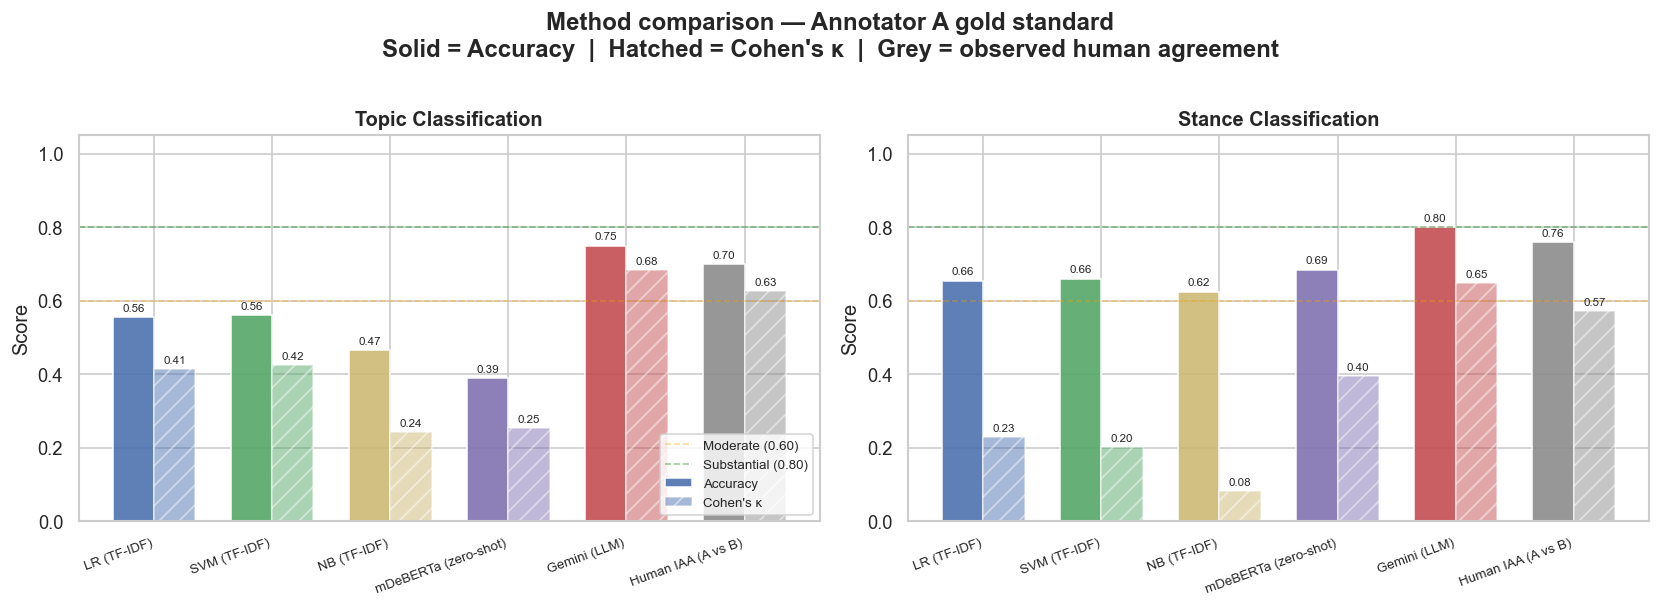

In [13]:
# Build a unified comparison table (using annotator A as reference)
ann = 'A'
df_g   = merged[ann]
texts  = df_g['tweet'].tolist()
y_top  = df_g['gold_topic'].tolist()
y_sta  = df_g['gold_stance'].tolist()

# Best traditional NLP result from cross-validation
top_row_best  = all_results[ann][all_results[ann]['Task']=='Topic'].sort_values(
    'Kappa (mean)', ascending=False).iloc[0]
sta_row_best  = all_results[ann][all_results[ann]['Task']=='Stance'].sort_values(
    'Kappa (mean)', ascending=False).iloc[0]

summary_rows = [
    # Traditional NLP
    {'Method': 'LR (TF-IDF)',   'Approach': 'Supervised (5-fold CV)',
     'Topic Acc': round(all_results[ann].query('Task=="Topic" and Model=="LR (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Topic κ':   round(all_results[ann].query('Task=="Topic" and Model=="LR (TF-IDF)"')["Kappa (mean)"].values[0],3),
     'Stance Acc':round(all_results[ann].query('Task=="Stance" and Model=="LR (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Stance κ':  round(all_results[ann].query('Task=="Stance" and Model=="LR (TF-IDF)"')["Kappa (mean)"].values[0],3)},
    {'Method': 'SVM (TF-IDF)',  'Approach': 'Supervised (5-fold CV)',
     'Topic Acc': round(all_results[ann].query('Task=="Topic" and Model=="SVM (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Topic κ':   round(all_results[ann].query('Task=="Topic" and Model=="SVM (TF-IDF)"')["Kappa (mean)"].values[0],3),
     'Stance Acc':round(all_results[ann].query('Task=="Stance" and Model=="SVM (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Stance κ':  round(all_results[ann].query('Task=="Stance" and Model=="SVM (TF-IDF)"')["Kappa (mean)"].values[0],3)},
    {'Method': 'NB (TF-IDF)',   'Approach': 'Supervised (5-fold CV)',
     'Topic Acc': round(all_results[ann].query('Task=="Topic" and Model=="NB (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Topic κ':   round(all_results[ann].query('Task=="Topic" and Model=="NB (TF-IDF)"')["Kappa (mean)"].values[0],3),
     'Stance Acc':round(all_results[ann].query('Task=="Stance" and Model=="NB (TF-IDF)"')["Accuracy (mean)"].values[0],3),
     'Stance κ':  round(all_results[ann].query('Task=="Stance" and Model=="NB (TF-IDF)"')["Kappa (mean)"].values[0],3)},
]

# Zero-shot row (if available)
if HAS_TRANSFORMERS:
    summary_rows.append({
        'Method': 'mDeBERTa (zero-shot)', 'Approach': 'Zero-shot (no training)',
        'Topic Acc': round(zs_topic_acc,3),  'Topic κ': round(zs_topic_kappa,3),
        'Stance Acc': round(zs_stance_acc,3),'Stance κ': round(zs_stance_kappa,3),
    })

# LLM row
summary_rows.append({
    'Method': 'Gemini (LLM)', 'Approach': 'Prompt-based LLM classification',
    'Topic Acc':  LLM_RESULTS[ann]['topic_acc'],
    'Topic κ':    LLM_RESULTS[ann]['topic_kappa'],
    'Stance Acc': LLM_RESULTS[ann]['stance_acc'],
    'Stance κ':   LLM_RESULTS[ann]['stance_kappa'],
})

# Human ceiling
summary_rows.append({
    'Method': 'Human IAA (A vs B)', 'Approach': 'Human ceiling',
    'Topic Acc':  0.700, 'Topic κ':   0.627,
    'Stance Acc': 0.760, 'Stance κ':  0.572,
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
method_palette = {
    'LR (TF-IDF)':           '#4C72B0',
    'SVM (TF-IDF)':          '#55A868',
    'NB (TF-IDF)':           '#CCB974',
    'mDeBERTa (zero-shot)':  '#8172B2',
    'Gemini (LLM)':          '#C44E52',
    'Human IAA (A vs B)':    '#8C8C8C',
}

for ax, (task_acc, task_kappa, title) in zip(
        axes,
        [('Topic Acc', 'Topic κ', 'Topic Classification'),
         ('Stance Acc', 'Stance κ', 'Stance Classification')]):
    methods = summary_df['Method']
    accs    = summary_df[task_acc]
    kappas  = summary_df[task_kappa]
    x = np.arange(len(methods))
    w = 0.35
    colors = [method_palette.get(m, '#999') for m in methods]

    b1 = ax.bar(x - w/2, accs,   w, color=colors, alpha=0.9, label='Accuracy', edgecolor='white')
    b2 = ax.bar(x + w/2, kappas, w, color=colors, alpha=0.5, label="Cohen's κ",
                edgecolor='white', hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.axhline(0.60, color='orange', ls='--', alpha=0.4, lw=1, label='Moderate (0.60)')
    ax.axhline(0.80, color='green',  ls='--', alpha=0.4, lw=1, label='Substantial (0.80)')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    if ax == axes[0]:
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    'Method comparison — Annotator A gold standard\n'
    'Solid = Accuracy  |  Hatched = Cohen\'s κ  |  '
    'Grey = observed human agreement',
    fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

This notebook compared the LLM-based classification with several traditional and modern NLP baselines. The comparison included supervised TF-IDF models, an unsupervised LDA topic model, a multilingual zero-shot transformer and the observed human inter-annotator agreement.

The supervised TF-IDF models provide useful and transparent baselines. Logistic Regression and Linear SVM perform reasonably well for topic classification, reaching moderate Cohen’s kappa values. This indicates that lexical patterns are informative for some political topics. However, their performance is more limited for stance classification, where the gap between accuracy and kappa shows that raw accuracy can overestimate model quality in an imbalanced setting.

Naive Bayes is the weakest supervised baseline in most cases. Its lower performance suggests that the independence assumptions of the model are too simple for political discourse, where meaning often depends on combinations of words, actors, targets and contextual references.

The LDA analysis shows that unsupervised topic modelling can recover some lexical structures in the corpus, especially around national politics and international affairs. However, its alignment with the LLM taxonomy is only partial. Some LDA topics map clearly to a dominant LLM category, while others mix several categories or split the same broad category into different lexical subtopics. This confirms that LDA is useful for exploratory analysis, but not as a direct substitute for semantic topic classification.

The zero-shot mDeBERTa model provides an additional semantic baseline. Its results are mixed. It performs better for stance than for topic classification, suggesting that stance labels are more compatible with the natural language inference format. However, its topic classification performance remains limited, probably because the thematic labels are broad, abstract and partially overlapping.

The LLM obtains the strongest results across both topic and stance classification. It clearly outperforms the traditional NLP baselines and the zero-shot transformer. Its performance also reaches agreement levels comparable to, and in this sample slightly above, the observed human inter-annotator agreement. This should not be interpreted as absolute superiority over human annotators, but as evidence that the LLM classifications are highly consistent with the annotation scheme.

The results support the use of prompt-based LLM classification as the main analytical approach for this study. Traditional NLP methods remain valuable as transparent and reproducible baselines, but they are less effective when the task requires semantic interpretation, contextual reasoning and the identification of implicit stance in political discourse.